# Laboratorio de regresión - 3

## Análisis exploratorio de datos y limpieza

|                |   |
:----------------|---|
| **Nombre**     |Juan Pablo Moran    |
| **Fecha**      07 de sep   |
| **Expediente** 753760|   |

En los laboratorios y clases anteriores se ha visto que el modelo de regresión propuesto puede ser cualquier combinación lineal de factores independientes. Por lo tanto hay un número infinito de posibles modelos de regresión teóricos. ¿Cómo podemos deducir qué tipo de modelo podríamos necesitar?

- Para saber que tipo de modelo conviene proponer primero hay que hacer un analisis exploratorio: graficar cada variable independiente contra la variable de respuesta y ver si la relacion se ve lineal, cuadratica o de otro tipo, y que tan dispersos estan los puntos. Tambien ayuda apoyarse en el conocimiento del fenomeno que se esta modelando (por ejemplo, si se sabe que una variable tiene un efecto que se satura o se acelera) y en pruebas de significancia estadistica para decidir que factores vale la pena incluir. En general conviene empezar con el modelo mas simple (lineal) y solo agregar complejidad (terminos polinomiales, interacciones, etc.) si el analisis exploratorio muestra que ese modelo simple no captura bien el comportamiento de los datos.

### EDA

El primer paso antes de poder proponer un modelo para predecir datos es entender el conjunto de datos con el que se está trabajando.
- ¿Cuántas muestras tiene?
- ¿Cuántos factores tiene?
- ¿Quién o qué hizo la recolección de las observaciones?
- ¿Cómo se hizo el muestreo?
- ¿En qué año se hicieron las observaciones?
- ¿En dónde se realizaron las observaciones?

El propósito de un análisis exploratorio de datos (EDA - Exploratory Data Analysis) es entender la naturaleza de los datos, comprender las relaciones existentes entre las variables para poder realizar hipótesis sobre cómo se relaciona la variable dependiente con las independientes.

#### Ejercicio 1: Dataset

Utiliza el dataset "Heart Prediction Dataset (Quantum)". Carga los datos y revisa qué factores contiene.

In [1]:
import pandas as pd

df = pd.read_csv("Heart Prediction Quantum Dataset.csv")
print(df.shape)
df.head()

(500, 6)


,Age,Gender,BloodPressure,Cholesterol,HeartRate,HeartDisease
0,68,Hombre,105.00,191,107,1
1,58,Mujer,97.00,249,89,0
2,44,Mujer,93.00,190,82,1
3,72,Hombre,93.00,183,101,1
4,37,Mujer,145.00,166,103,1


Para cada factor, escribe qué significa cada variable.
- ¿Qué tipo de datos se observaron?
    - Numéricos
        - Enteros
        - Flotantes
    - Categóricos
        - Ordinales
        - No ordinales
- ¿Qué rango de valores sería esperado que contuviera cada factor? E.g. No esperaría encontrar un valor de Age de $-4$.

Investiga los valores esperados para variables que no entiendas como BloodPressure, Cholesterol, etc.

- **Age**: edad de la persona, en anios. Numerica entera. Se esperaria un rango de edad adulta razonable, por ejemplo entre 18 y 100 anios aproximadamente.
- **Gender**: genero de la persona (Hombre/Mujer). Categorica no ordinal.
- **BloodPressure**: presion arterial (sistolica), en mmHg. Numerica flotante. En adultos un valor normal suele estar entre 90 y 180 mmHg aproximadamente; fuera de ese rango seria raro.
- **Cholesterol**: nivel de colesterol en sangre, en mg/dL. Numerica entera. Valores tipicos van de 125 a 300 mg/dL aproximadamente.
- **HeartRate**: frecuencia cardiaca en reposo, en latidos por minuto (bpm). Numerica entera. Se espera entre 60 y 120 bpm aproximadamente.
- **HeartDisease**: variable de respuesta binaria que indica si la persona tiene (1) o no tiene (0) alguna enfermedad cardiaca. Categorica ordinal (binaria).

A partir de lo investigado, describe el dataset con tus palabras.

- Es un dataset de 500 pacientes con 5 posibles factores (Age, Gender, BloodPressure, Cholesterol, HeartRate) para predecir si la persona tiene o no una enfermedad cardiaca (HeartDisease). Combina variables numericas (edad, presion, colesterol, frecuencia cardiaca) con una variable categorica (genero), y la variable de respuesta es binaria.

#### Ejercicio 2: Factores

Ahora que se tiene un mejor entendimiento del dataset y de los valores que podría tener cada variable, es momento de revisar que las observaciones en el dataset estén dentro de ese rango esperado.

Crea un histograma para cada uno de los factores para ver el rango de los valores medidos y su distribución. 

ValueError: Unable to parse string "97,00" at position 45

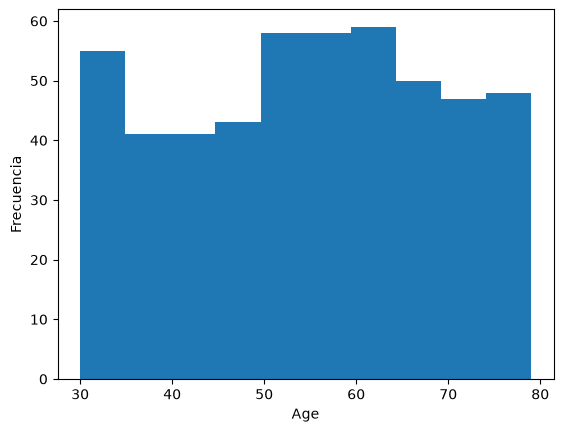

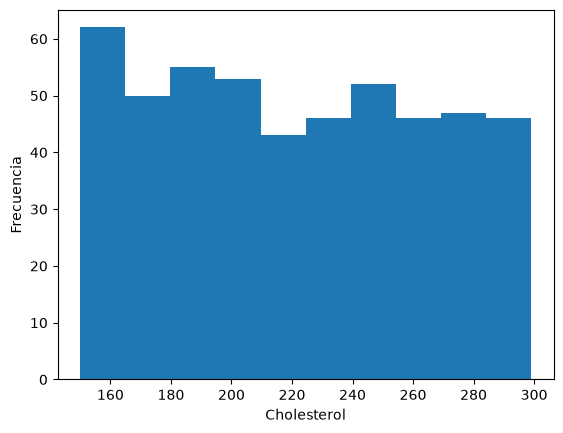

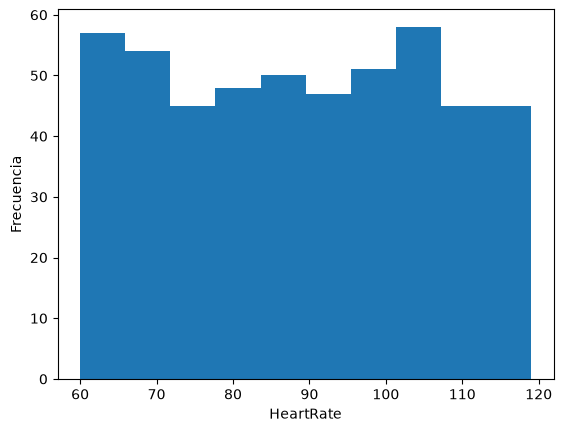

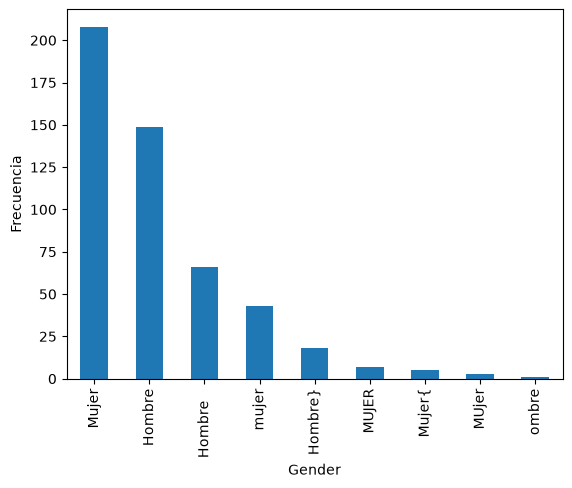

<Figure size 640x480 with 0 Axes>

In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["Age"])
plt.xlabel("Age")
plt.ylabel("Frecuencia")

plt.figure()
plt.hist(df["Cholesterol"])
plt.xlabel("Cholesterol")
plt.ylabel("Frecuencia")

plt.figure()
plt.hist(df["HeartRate"])
plt.xlabel("HeartRate")
plt.ylabel("Frecuencia")

plt.figure()
df["Gender"].value_counts().plot(kind="bar")
plt.xlabel("Gender")
plt.ylabel("Frecuencia")

plt.figure()
plt.hist(pd.to_numeric(df["BloodPressure"], errors="coerce"))
plt.xlabel("BloodPressure")
plt.ylabel("Frecuencia")

¿Parecen correctas estas distribuciones? ¿Qué valores atípicos encontraste? ¿Alguna inconsistencia? ¿Los problemas encontrados podrían ser casos reales?

- Age, Cholesterol y HeartRate se ven razonables, sin valores fuera de lo esperado. En Gender aparecen 9 categorias distintas en vez de solo 2 (Hombre/Mujer), por diferencias de mayusculas/minusculas, espacios de mas y simbolos extra, y un typo con la "h" faltante ("ombre"). En BloodPressure el histograma sale incompleto porque 126 registros usan coma como separador decimal (estilo europeo) en lugar de punto, y esos valores no se pudieron convertir a numero; no son valores atipicos, es un problema de formato que hay que corregir antes de poder analizar la variable.

#### Ejercicio 3: Limpieza

Es muy común que haya errores al registrar observaciones. Puede ser que personas diferentes hayan registrado datos con un estilo diferente, o que haya habido un error de dedo. También podrían haber registros duplicados, o datos faltantes.

Por ejemplo, la columna BloodPressure tiene dos estilos diferentes para el punto decimal (americano y europeo).

Utiliza `pandas.Series.str.replace` para cambiar el punto decimal de europeo a americano en la columna de BloodPressure. Después, cambia el tipo de dato de la columna a numérico. Dibuja el histograma de la variable corregida.

In [ ]:
df["BloodPressure"] = df["BloodPressure"].str.replace(",", ".")
df["BloodPressure"] = pd.to_numeric(df["BloodPressure"])

plt.figure()
plt.hist(df["BloodPressure"])
plt.xlabel("BloodPressure")
plt.ylabel("Frecuencia")

La columna Gender tiene también errores de dedo y de estilo. Utiliza `pandas.Series.unique()` para encontrar las formas diferentes en las que se escribió "Hombre" y "Mujer".

In [ ]:
df["Gender"].unique()

La diferencia entre una mayúscula y minúscula para una computadora tiene que ver con la tabla ASCII. Para evitar esta variación utiliza `pandas.Series.str.lower()` para convertir todos las mayúsculas en minúsculas. Guarda el resultado en una variable auxiliar. Utiliza `unique()` una vez más para ver el resultado.

In [ ]:
genero_min = df["Gender"].str.lower()
genero_min.unique()

Observamos que hay errores como espacios en blanco o errores de dedo. Utiliza `pandas.Series.str.rstrip("xxx")` para limpiar los caracteres indeseados.

In [ ]:
genero_limpio = genero_min.str.rstrip(" {}")
genero_limpio.unique()

Utiliza un filtro para corregir el typo de la 'h' faltante para la categoría "hombre".

In [ ]:
genero_limpio[genero_limpio == "ombre"] = "hombre"
genero_limpio.unique()

Asigna "hombre"=1 y "mujer"=0 (Ojo con los tipos de dato. Considera que 0 es diferente a "0").

In [ ]:
genero_num = genero_limpio.replace({"hombre": 1, "mujer": 0})
genero_num.unique()

Reescribe el resultado en el dataset original.

In [ ]:
df["Gender"] = genero_num
df.head()

Para asegurarnos que no haya duplicados, utiliza `pd.DataFrame.drop_duplicates()`

In [ ]:
df = df.drop_duplicates()
df.shape

Para los valores faltantes se podría imputar, pero por ahora sólo elimínalos (si es que hay) con `pd.DataFrame.dropna()`

In [ ]:
df = df.dropna()
df.shape

#### Ejercicio 4: Verificación

Ahora que entendemos qué significan nuestras variables y que las limpiamos, vuelve a generar histogramas para cada variable.

In [ ]:
plt.figure()
plt.hist(df["Age"])
plt.xlabel("Age")
plt.ylabel("Frecuencia")

plt.figure()
plt.hist(df["BloodPressure"])
plt.xlabel("BloodPressure")
plt.ylabel("Frecuencia")

plt.figure()
plt.hist(df["Cholesterol"])
plt.xlabel("Cholesterol")
plt.ylabel("Frecuencia")

plt.figure()
plt.hist(df["HeartRate"])
plt.xlabel("HeartRate")
plt.ylabel("Frecuencia")

plt.figure()
df["Gender"].value_counts().plot(kind="bar")
plt.xlabel("Gender")
plt.ylabel("Frecuencia")

Encuentra la siguiente información para las variables numéricas:
- media
- mediana
- desviación estándar
- mínimo
- máximo

Genera un diagrama de caja para cada una. ¿Consideras que hay valores atípicos (outliers)?

In [ ]:
df[["Age","BloodPressure","Cholesterol","HeartRate"]].describe()

In [ ]:
plt.figure()
plt.boxplot(df["Age"])
plt.xlabel("Age")

plt.figure()
plt.boxplot(df["BloodPressure"])
plt.xlabel("BloodPressure")

plt.figure()
plt.boxplot(df["Cholesterol"])
plt.xlabel("Cholesterol")

plt.figure()
plt.boxplot(df["HeartRate"])
plt.xlabel("HeartRate")

- No se observan valores atipicos claros en ninguna variable numerica: los diagramas de caja muestran los datos dentro de un rango razonable (Age entre 30 y 79 anios, BloodPressure entre 90 y 179, Cholesterol entre 150 y 299, HeartRate entre 60 y 119), sin puntos marcados fuera de los bigotes.

Encuentra la siguiente información para las variables categóricas:
- tabla de frecuencias
- valores únicos

In [ ]:
print(df["Gender"].value_counts())
print(df["Gender"].unique())
print(df["HeartDisease"].value_counts())
print(df["HeartDisease"].unique())

## Referencia

Dataset original tomado de: https://www.kaggle.com/datasets/shantanugarg274/heart-prediction-dataset-quantum